# Data Cleaning & Exploratory Data Analysis

# 1. Loading Dataset

In [623]:
import pandas as pd
df = pd.read_csv("data/covid19_patient_symptoms_diagnosis.csv")
print(df.shape)

(5000, 18)


#### The COVID-19 patient symptoms and diagnosis dataset was loaded successfully.The data set has 5,000 rows and 18 columns.Each row represents a unique patient record.The dataset includes demographic information, symptom indicators, clinical measurements, and finally, COVID diagnostic result.This dataset was selected because it allows us to explore the relationship between patient symptoms, demographics, and COVID-19 outcomes.

# 2. Initial Data Inspection

In [624]:
print(df.head())

   patient_id  age  gender  fever  dry_cough  sore_throat  fatigue  headache  \
0           1   52    Male      1          0            1        1         0   
1           2   15    Male      0          0            0        1         1   
2           3   72    Male      1          0            1        0         0   
3           4   61  Female      0          0            1        1         1   
4           5   21  Female      1          1            0        0         0   

   shortness_of_breath  loss_of_smell  loss_of_taste  oxygen_level  \
0                    0              0              0            98   
1                    0              0              0            85   
2                    1              0              1            99   
3                    0              1              1            86   
4                    1              0              1            90   

   body_temperature comorbidity  travel_history  contact_with_patient  \
0              37.1    Di

In [625]:
print(df.columns)

Index(['patient_id', 'age', 'gender', 'fever', 'dry_cough', 'sore_throat',
       'fatigue', 'headache', 'shortness_of_breath', 'loss_of_smell',
       'loss_of_taste', 'oxygen_level', 'body_temperature', 'comorbidity',
       'travel_history', 'contact_with_patient', 'chest_pain', 'covid_result'],
      dtype='str')


In [626]:

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   str    
 3   fever                 5000 non-null   int64  
 4   dry_cough             5000 non-null   int64  
 5   sore_throat           5000 non-null   int64  
 6   fatigue               5000 non-null   int64  
 7   headache              5000 non-null   int64  
 8   shortness_of_breath   5000 non-null   int64  
 9   loss_of_smell         5000 non-null   int64  
 10  loss_of_taste         5000 non-null   int64  
 11  oxygen_level          5000 non-null   int64  
 12  body_temperature      5000 non-null   float64
 13  comorbidity           2275 non-null   str    
 14  travel_history        5000 non-null   int64  
 15  contact_with_patient  5000 non-n

In [627]:
print(df.dtypes)

patient_id                int64
age                       int64
gender                      str
fever                     int64
dry_cough                 int64
sore_throat               int64
fatigue                   int64
headache                  int64
shortness_of_breath       int64
loss_of_smell             int64
loss_of_taste             int64
oxygen_level              int64
body_temperature        float64
comorbidity                 str
travel_history            int64
contact_with_patient      int64
chest_pain                int64
covid_result              int64
dtype: object


# 3. Demographic Summary

In [628]:
# Basic demographic summary

total_records = len(df)
print("Total Records in Dataset:", total_records)

gender_summary = df['gender'].value_counts()
print("\n--- Gender Breakdown ---")
print(gender_summary)

mean_age = df['age'].mean()
print(f"\nMean Age of Dataset: {mean_age:.2f} (Rounded: {round(mean_age)})")
print("\n--- Age Descriptive Statistics ---")
print(df['age'].describe())

Total Records in Dataset: 5000

--- Gender Breakdown ---
gender
Female    2514
Male      2486
Name: count, dtype: int64

Mean Age of Dataset: 44.38 (Rounded: 44)

--- Age Descriptive Statistics ---
count    5000.000000
mean       44.380600
std        25.551632
min         1.000000
25%        22.000000
50%        44.000000
75%        66.000000
max        89.000000
Name: age, dtype: float64


#### The dataset contains records from patients ranging across multiple age groups with a mean age of approximately 44 years. The gender breakdown shows a relatively balanced distribution between male and female patients. These demographic statistics establish the baseline profile of the patient population and will be referenced throughout the analysis when interpreting symptom and diagnosis patterns across different groups.

# 4.corelation matrix

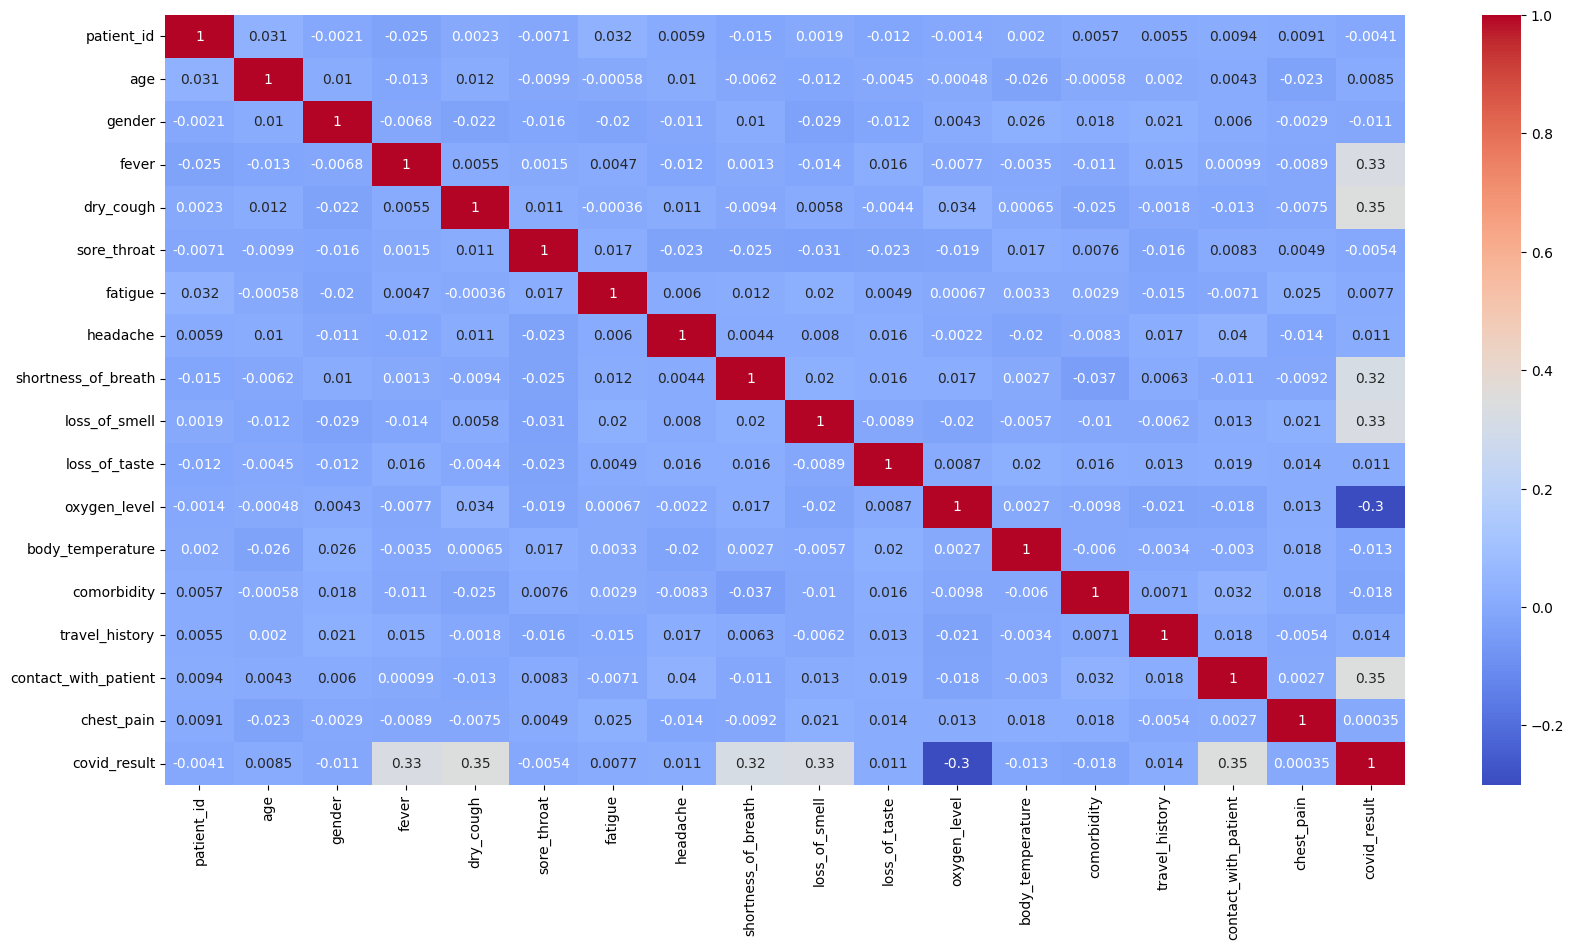

In [629]:
import matplotlib.pyplot as plt
import seaborn as sns
df['gender'] = df['gender'].astype('category').map({'Male': 0, 'Female': 1})
df['comorbidity'] = df['comorbidity'].map({'Asthma': 0, 'Diabetes': 1, 'Heart Disease': 2, 'no chronic disease': 3})

plt.figure(figsize=(20,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# 5. Data Cleaning — Missing Values and Duplicates

In [630]:
df = pd.read_csv("data/covid19_patient_symptoms_diagnosis.csv")
print(df.isnull().sum())

patient_id                 0
age                        0
gender                     0
fever                      0
dry_cough                  0
sore_throat                0
fatigue                    0
headache                   0
shortness_of_breath        0
loss_of_smell              0
loss_of_taste              0
oxygen_level               0
body_temperature           0
comorbidity             2725
travel_history             0
contact_with_patient       0
chest_pain                 0
covid_result               0
dtype: int64


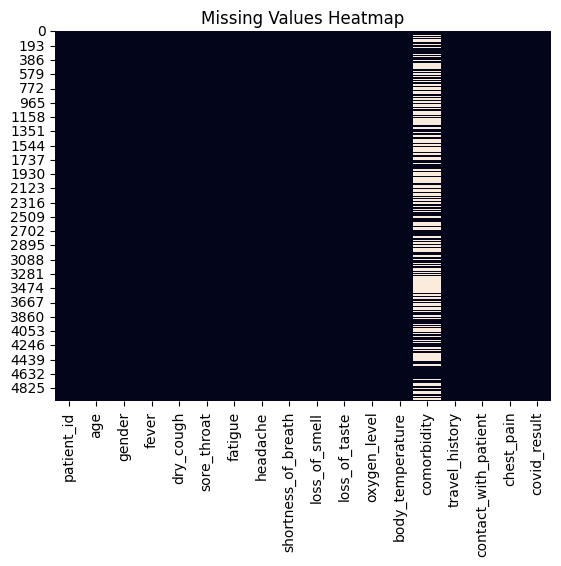

In [631]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [632]:
comorbidity_summary = df['comorbidity'].value_counts()
print(comorbidity_summary)

comorbidity
Diabetes         1001
Heart Disease     792
Asthma            482
Name: count, dtype: int64


In [633]:
df["comorbidity"] = df["comorbidity"].fillna("no chronic disease")

In [634]:
print(df.isnull().sum())

patient_id              0
age                     0
gender                  0
fever                   0
dry_cough               0
sore_throat             0
fatigue                 0
headache                0
shortness_of_breath     0
loss_of_smell           0
loss_of_taste           0
oxygen_level            0
body_temperature        0
comorbidity             0
travel_history          0
contact_with_patient    0
chest_pain              0
covid_result            0
dtype: int64


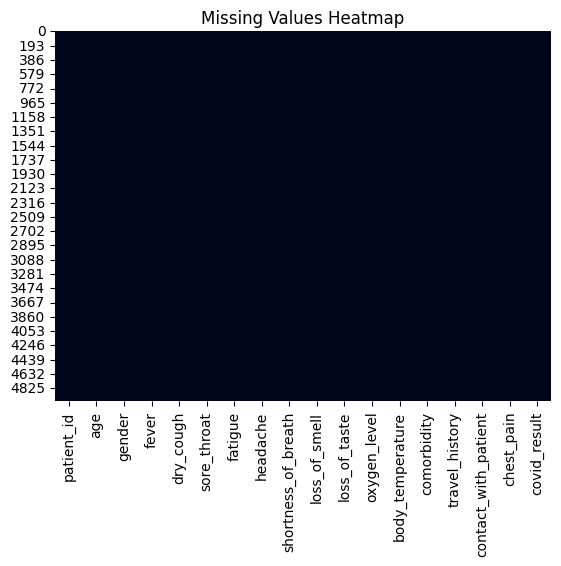

In [635]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [636]:
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool


#### **Duplicates:** No duplicate rows were found in the dataset, confirming that each patient record is unique and no rows need to be removed on this basis.

#### **Missing Values:** The only column with missing values is the comorbidity column, which contains 2,725 missing entries representing 54.5% of the dataset. All other columns are complete with zero missing values.

#### **Why this Matters:** Rather than dropping the 2,725 rows with missing comorbidity values, we filled them with the label "No Chronic disease". This decision was made for two reasons. First, dropping over half the dataset would severely reduce the reliability and representativeness of our analysis. Second, the absence of a recorded comorbidity is itself clinically meaningful information indicating the patient has no known underlying condition. Replacing NaN with "No Comorbidities" preserves this information rather than discarding it.



# 6. Age Distribution Visualization

---Patient Count per Age---
age
1     56
2     57
3     61
4     56
5     55
      ..
85    50
86    66
87    65
88    54
89    55
Name: count, Length: 89, dtype: int64

Total Patient: 5000


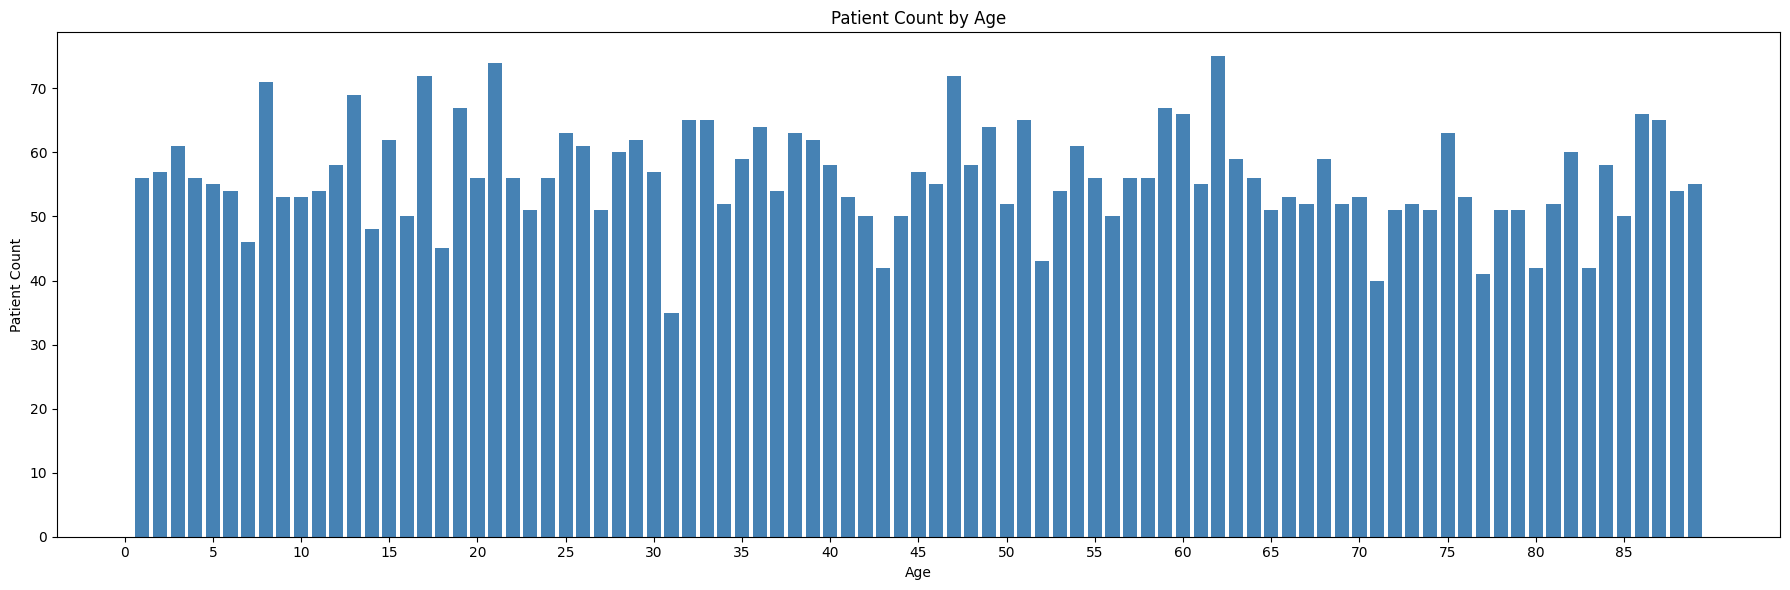

In [637]:
age_count = df['age'].value_counts().sort_index()
print("---Patient Count per Age---")
print(age_count)
print(f"\nTotal Patient: {age_count.sum()}")
plt.figure(figsize=(18, 6))
plt.bar(age_count.index, age_count.values, color='steelblue')
plt.title('Patient Count by Age')
plt.xlabel('Age')
plt.ylabel('Patient Count')
plt.xticks(range(0, 90, 5))
plt.tight_layout()
plt.show()

#### The bar chart above displays the count of patients at each individual age. The distribution appears relatively spread across the age range with no single age group dominating the dataset. This visualization confirms the earlier finding that no age outliers are present, as there are no extreme spikes or gaps at the boundaries of the distribution. The spread across age groups makes this dataset well suited for age-based subgroup analysis.

# 7. Outlier Detection — Age, Oxygen Level & Body Temperature

In [638]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_upper = df[df['age'] > upper_bound]
outliers_lower = df[df['age'] < lower_bound]

print(outliers_upper)
print(outliers_lower)

Empty DataFrame
Columns: [patient_id, age, gender, fever, dry_cough, sore_throat, fatigue, headache, shortness_of_breath, loss_of_smell, loss_of_taste, oxygen_level, body_temperature, comorbidity, travel_history, contact_with_patient, chest_pain, covid_result]
Index: []
Empty DataFrame
Columns: [patient_id, age, gender, fever, dry_cough, sore_throat, fatigue, headache, shortness_of_breath, loss_of_smell, loss_of_taste, oxygen_level, body_temperature, comorbidity, travel_history, contact_with_patient, chest_pain, covid_result]
Index: []


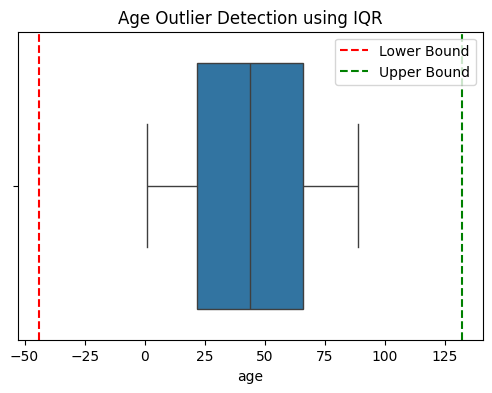

In [639]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df['age'])

plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound, color='green', linestyle='--', label='Upper Bound')

plt.title("Age Outlier Detection using IQR")
plt.legend()

plt.show()

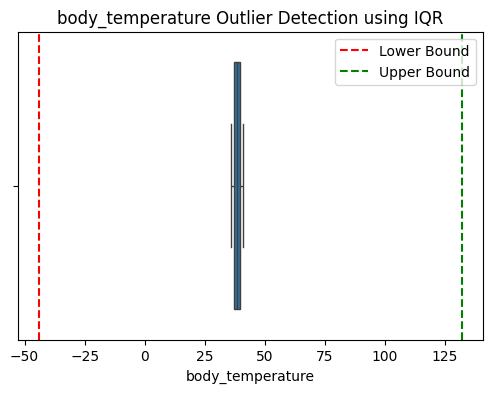

In [640]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df['body_temperature'])

plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound, color='green', linestyle='--', label='Upper Bound')

plt.title("body_temperature Outlier Detection using IQR")
plt.legend()

plt.show()

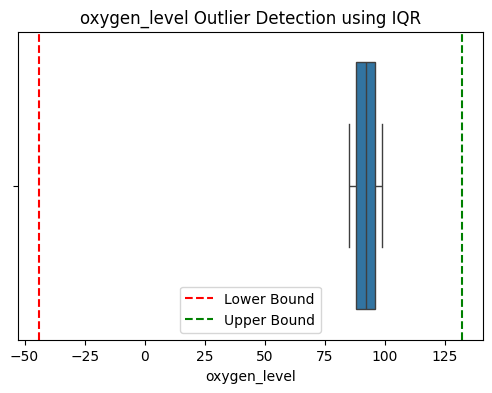

In [641]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df['oxygen_level'])

plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound, color='green', linestyle='--', label='Upper Bound')

plt.title("oxygen_level Outlier Detection using IQR")
plt.legend()

plt.show()

#### We applied the Interquartile Range (IQR) method to detect outliers across all three numerical columns in the dataset: age, oxygen level, and body temperature. This method flags any value that falls below Q1 - 1.5 times the IQR or above Q3 + 1.5 times the IQR as a potential outlier.

#### **Finding: Zero outliers were detected across all three columns!** All patient ages, oxygen readings, and body temperatures fall within statistically reasonable ranges, confirming the dataset is clean and no rows need to be removed on this basis.

#### Things to Consider
#### **Normal Threshold:** A normal threshold is the baseline measurement for a healthy individual. Two clinically significant observations emerged from the descriptive statistics when comparing the dataset against these thresholds.

#### **Oxygen Level — Below Normal Threshold:**
#### The normal threshold for oxygen level is 95%. A healthy individual should have an oxygen saturation between 95% and 100%. The mean oxygen level across all patients in this dataset is 91.9%, which falls below the normal threshold of 95%. This indicates that the average patient in this dataset was already experiencing reduced oxygen saturation, which is one of the most recognized warning signs of COVID-19 and is consistent with a population of patients presenting with active respiratory distress.

#### **Body Temperature — Above Normal Threshold:**  The normal threshold for body temperature is 37°C or 98.6°F. A healthy individual should have a body temperature at or below this value. The mean body temperature across all patients in this dataset is 38.5°C or 101.3°F, which sits above the normal threshold. This indicates that the average patient in this dataset was presenting with a fever at the time of their COVID-19 diagnosis, consistent with fever being one of the most commonly reported symptoms of COVID-19.


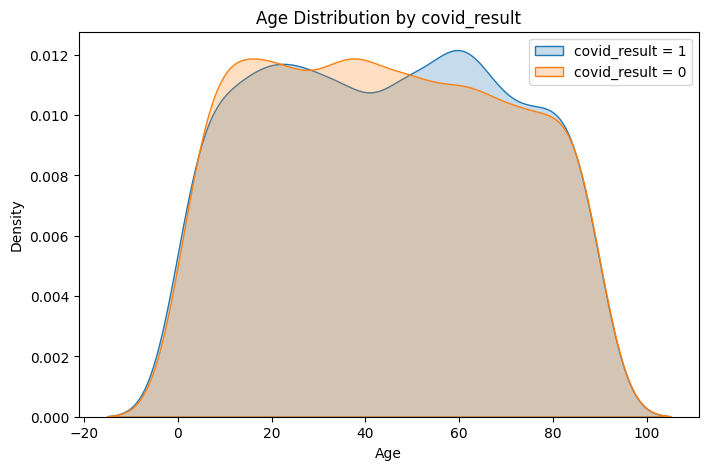

In [642]:
plt.figure(figsize=(8,5))

sns.kdeplot(data=df[df['covid_result']== 1 ], x='age', label='covid_result = 1', fill=True)
sns.kdeplot(data=df[df['covid_result']== 0], x='age', label='covid_result = 0', fill=True)

plt.title('Age Distribution by covid_result')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

# 8.Performing Groupby and Aggregation

In [643]:
print(df.groupby('comorbidity')['age'].agg(['mean', 'median', 'min', 'max', 'count']))

                         mean  median  min  max  count
comorbidity                                           
Asthma              43.719917    44.0    1   89    482
Diabetes            44.663337    45.0    1   89   1001
Heart Disease       43.872475    44.0    1   89    792
no chronic disease  44.541284    44.0    1   89   2725


In [644]:

bins = [0, 18, 35, 50, 60, 80, 100]
labels = ['Minors (0-17)', 'Young Adult (18-34)', 'Adult (35-49)',
          'Middle Aged (50-59)', 'Senior (60-79)', 'Elderly (80+)']

df['age_categories'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
category_counts = df['age_categories'].value_counts().sort_index()
total_patients = category_counts.sum()

print("--- Patient Count per Age Category ---")
print(category_counts)
print(f"\nTotal Patients Across All Groups: {total_patients}")


--- Patient Count per Age Category ---
age_categories
Minors (0-17)           975
Young Adult (18-34)     976
Adult (35-49)           861
Middle Aged (50-59)     560
Senior (60-79)         1084
Elderly (80+)           544
Name: count, dtype: int64

Total Patients Across All Groups: 5000


#### To enable more impactful group-level analysis, patients were binned into five age categories based on standard demographic groupings:
#### - Minors (0-17)
#### - Young Adults (18-34)
#### - Adults (35-49)
#### - Middle Aged (50-59)
#### - Senior (60+)

#### This categorization allows us to compare symptom patterns, COVID positive rates, and clinical measurements across life stage groups rather than individual ages, which produces more interpretable and actionable insights.

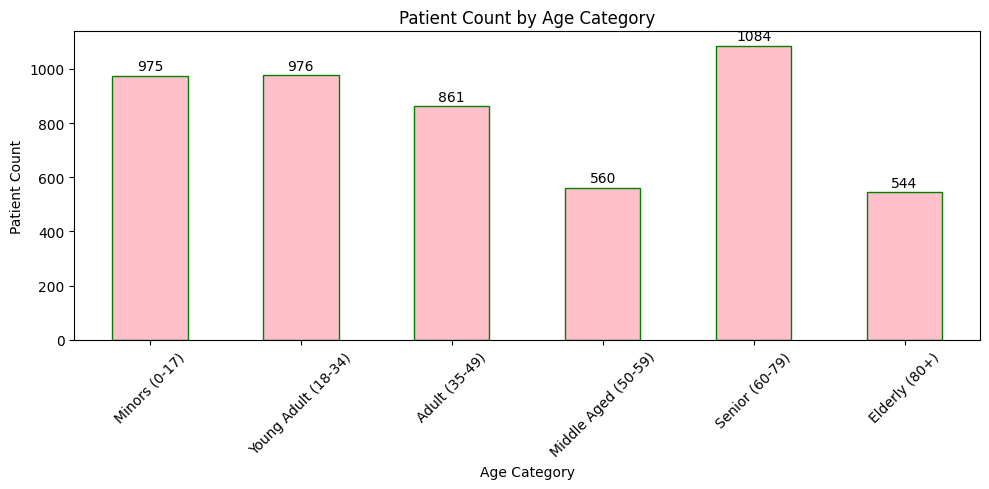

In [645]:
fig, ax = plt.subplots(figsize=(10, 5))

category_counts.plot(kind='bar', ax=ax, color='pink', edgecolor='green')

ax.set_title('Patient Count by Age Category')
ax.set_xlabel('Age Category')
ax.set_ylabel('Patient Count')
ax.tick_params(axis='x', rotation=45)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# 9. Age and Gender Breakdown

In [646]:
# 9. Age and gender breakdown by group

print("--- Age Statistics by Gender ---")
print(df.groupby('gender')['age'].agg(['mean', 'median', 'min', 'max', 'count']))

gender_within_age = pd.crosstab(df['age_categories'], df['gender'], normalize='index') * 100
age_within_gender = pd.crosstab(df['age_categories'], df['gender'], normalize='columns') * 100

print("\n--- Gender Split WITHIN Each Age Category (%) ---")
print(gender_within_age.map('{:.2f}%'.format))

print("\n--- Age Distribution WITHIN Each Gender (%) ---")
print(age_within_gender.map('{:.2f}%'.format))

--- Age Statistics by Gender ---
             mean  median  min  max  count
gender                                    
Female  44.638425    45.0    1   89   2514
Male    44.119871    44.0    1   89   2486

--- Gender Split WITHIN Each Age Category (%) ---
gender               Female    Male
age_categories                     
Minors (0-17)        48.62%  51.38%
Young Adult (18-34)  50.92%  49.08%
Adult (35-49)        52.03%  47.97%
Middle Aged (50-59)  47.68%  52.32%
Senior (60-79)       51.38%  48.62%
Elderly (80+)        49.82%  50.18%

--- Age Distribution WITHIN Each Gender (%) ---
gender               Female    Male
age_categories                     
Minors (0-17)        18.85%  20.15%
Young Adult (18-34)  19.77%  19.27%
Adult (35-49)        17.82%  16.61%
Middle Aged (50-59)  10.62%  11.79%
Senior (60-79)       22.16%  21.20%
Elderly (80+)        10.78%  10.98%


#### This section examines how age and gender intersect across the dataset. The cross tabulation between age categories and gender shows the proportion of male and female patients within each age group. This breakdown helps identify whether any age group skews heavily toward one gender, which could influence how we interpret symptom and diagnosis patterns within those groups.

# 10. Overall Symptom Frequency

In [647]:
# 10. Overall symptom frequency and rate by COVID result

symptoms = ['fever', 'dry_cough', 'sore_throat', 'fatigue', 'headache',
            'shortness_of_breath', 'loss_of_smell', 'loss_of_taste', 'chest_pain']

symptom_counts = df[symptoms].sum().sort_values(ascending=False)
symptom_pct = (symptom_counts / len(df) * 100).round(2)

print('--- Overall Symptom Frequency ---')
print(pd.DataFrame({'Count': symptom_counts, 'Percent (%)': symptom_pct}))

symptom_by_result = df.groupby('covid_result')[symptoms].mean() * 100
symptom_by_result = symptom_by_result.rename(index={0: 'Negative', 1: 'Positive'})  # FIXED
print('\n--- Symptom Rate by COVID Result (%) ---')
print(symptom_by_result.T.round(2))

--- Overall Symptom Frequency ---
                     Count  Percent (%)
fatigue               2949        58.98
fever                 2837        56.74
dry_cough             2466        49.32
headache              2224        44.48
sore_throat           2080        41.60
shortness_of_breath   1742        34.84
chest_pain            1530        30.60
loss_of_smell         1497        29.94
loss_of_taste         1464        29.28

--- Symptom Rate by COVID Result (%) ---
covid_result         Negative  Positive
fever                   39.83     72.35
dry_cough               31.29     65.96
sore_throat             41.88     41.35
fatigue                 58.58     59.35
headache                43.92     45.00
shortness_of_breath     19.04     49.42
loss_of_smell           14.25     44.42
loss_of_taste           28.75     29.77
chest_pain              30.58     30.62


#### The symptom frequency table shows how commonly each symptom appeared across all patients in the dataset. Some symptoms appear far more frequently than others, suggesting they may be stronger indicators of COVID-19 presence. This frequency baseline will be used later to compare symptom rates between COVID positive and negative patient groups to identify which symptoms carry the most diagnostic weight.

# 11. COVID Positive Rate and Symptom Burden by Age Group

In [648]:

df['symptom_count'] = df[symptoms].sum(axis=1)

print("--- Avg Symptom Count & COVID Positive Rate by Age Group ---")
age_summary = df.groupby('age_categories', observed=False).agg(
    Avg_Symptoms=('symptom_count', 'mean'),
    Positive_Rate=('covid_result', 'mean'),
    Patient_Count=('patient_id', 'count')
)
age_summary['Positive_Rate'] = (age_summary['Positive_Rate'] * 100).round(2)
age_summary['Avg_Symptoms'] = age_summary['Avg_Symptoms'].round(2)
print(age_summary)

--- Avg Symptom Count & COVID Positive Rate by Age Group ---
                     Avg_Symptoms  Positive_Rate  Patient_Count
age_categories                                                 
Minors (0-17)                3.79          51.38            975
Young Adult (18-34)          3.79          52.15            976
Adult (35-49)                3.73          50.06            861
Middle Aged (50-59)          3.79          53.39            560
Senior (60-79)               3.69          53.23           1084
Elderly (80+)                3.78          52.02            544


#### This summary table shows the average symptom count and COVID positive rate for each age category. Higher average symptom counts in a group suggest a more severe disease presentation. Differences in COVID positive rates across age groups help identify which populations were most affected and will inform the hypothesis testing section of this project.

# 12. Symptom Rate by Gender and COVID Result Combined

In [649]:
print("--- Symptom Rate by Gender & COVID Result (%) ---")
gender_covid_symptoms = df.groupby(['gender', 'covid_result'])[symptoms].mean() * 100


display_df = gender_covid_symptoms.copy()
display_df = display_df.rename(index={0: 'Negative', 1: 'Positive'}, level='covid_result')  # FIXED
print(display_df.round(2).T)

--- Symptom Rate by Gender & COVID Result (%) ---
gender                Female              Male         
covid_result        Negative Positive Negative Positive
fever                  39.51    72.33    40.17    72.36
dry_cough              30.08    65.38    32.54    66.54
sore_throat            41.07    40.57    42.71    42.11
fatigue                58.69    57.34    58.47    61.33
headache               43.44    44.44    44.41    45.56
shortness_of_breath    20.08    49.69    17.97    49.16
loss_of_smell          13.20    43.12    15.34    45.71
loss_of_taste          27.87    29.52    29.66    30.02
chest_pain             29.18    31.68    32.03    29.56


#### This combined breakdown shows symptom rates split by both gender and COVID result simultaneously. This allows us to see whether symptom patterns between positive and negative patients differ by gender, adding a layer of depth to the symptom analysis beyond what single-variable groupings reveal.

# 13. Symptom Rate by Comorbidity Group

In [650]:

symptom_by_comorbidity = df.groupby('comorbidity')[symptoms].mean() * 100

print("--- Symptom Rate by Comorbidity Group (%) ---")
print(symptom_by_comorbidity.T.round(2))

print("\n--- Most Common Symptom Per Comorbidity Group ---")
print(symptom_by_comorbidity.idxmax(axis=1))

--- Symptom Rate by Comorbidity Group (%) ---
comorbidity          Asthma  Diabetes  Heart Disease  no chronic disease
fever                 58.92     54.85          56.82               57.03
dry_cough             50.62     47.85          46.97               50.31
sore_throat           43.15     42.46          43.94               40.33
fatigue               62.24     58.64          61.87               57.69
headache              47.30     44.36          45.71               43.67
shortness_of_breath   37.14     34.47          32.32               35.30
loss_of_smell         30.29     30.47          29.17               29.91
loss_of_taste         26.56     29.47          28.91               29.80
chest_pain            29.46     30.37          31.69               30.57

--- Most Common Symptom Per Comorbidity Group ---
comorbidity
Asthma                fatigue
Diabetes              fatigue
Heart Disease         fatigue
no chronic disease    fatigue
dtype: str


### This table shows the percentage of patients in each comorbidity group who reported each symptom. Differences in symptom rates across groups suggest that underlying health conditions may influence how COVID-19 presents in patients. Groups with notably higher rates of specific symptoms compared to others may warrant closer clinical attention and further statistical testing.

# 14. COVID Positive Rate and Symptom Burden by Comorbidity Group

In [651]:
comorbidity_summary = df.groupby('comorbidity').agg(  
    Avg_Symptoms=('symptom_count', 'mean'),
    Positive_Rate=('covid_result', 'mean'),
    Patient_Count=('patient_id', 'size')
)
comorbidity_summary['Positive_Rate'] = (comorbidity_summary['Positive_Rate'] * 100).round(2)
comorbidity_summary['Avg_Symptoms'] = comorbidity_summary['Avg_Symptoms'].round(2)
print('--- Avg Symptom Count & COVID Positive Rate by Comorbidity ---')
print(comorbidity_summary)

--- Avg Symptom Count & COVID Positive Rate by Comorbidity ---
                    Avg_Symptoms  Positive_Rate  Patient_Count
comorbidity                                                   
Asthma                      3.86          52.28            482
Diabetes                    3.73          50.95           1001
Heart Disease               3.77          49.87            792
no chronic disease          3.75          52.95           2725


#### This summary table combines average symptom count and COVID positive rate for each comorbidity group. If patients with Diabetes or Heart Disease show meaningfully higher positive rates than those with no comorbidity, this finding supports the clinical understanding that pre-existing conditions are a significant COVID-19 risk factor.

# 15. Symptom Dominance by Comorbidity Group

In [652]:
print("--- Which Comorbidity Group Has the Highest Rate of Each Symptom ---")
for symptom in symptoms:
    top_group = symptom_by_comorbidity[symptom].idxmax()
    top_pct = symptom_by_comorbidity[symptom].max().round(2)
    diff = (symptom_by_comorbidity[symptom].max() - symptom_by_comorbidity[symptom].min()).round(2)
    print(f"{symptom:<25} → {top_group} ({top_pct}%)  |  Difference: {diff}%")

--- Which Comorbidity Group Has the Highest Rate of Each Symptom ---
fever                     → Asthma (58.92%)  |  Difference: 4.08%
dry_cough                 → Asthma (50.62%)  |  Difference: 3.65%
sore_throat               → Heart Disease (43.94%)  |  Difference: 3.61%
fatigue                   → Asthma (62.24%)  |  Difference: 4.55%
headache                  → Asthma (47.3%)  |  Difference: 3.63%
shortness_of_breath       → Asthma (37.14%)  |  Difference: 4.81%
loss_of_smell             → Diabetes (30.47%)  |  Difference: 1.3%
loss_of_taste             → no chronic disease (29.8%)  |  Difference: 3.24%
chest_pain                → Heart Disease (31.69%)  |  Difference: 2.23%


#### This analysis identifies which comorbidity group reported the highest rate of each individual symptom and quantifies the spread between the highest and lowest groups. A large difference indicates that the symptom may be particularly linked to a specific underlying condition, which is valuable clinical context for interpreting the modeling results later.

# 16. COVID Result Demographic Summary

In [653]:
covid_demo = df.groupby('covid_result').agg(
    Patient_Count=('patient_id', 'count'),
    Avg_Age=('age', 'mean'),
    Min_Age=('age', 'min'),
    Max_Age=('age', 'max'),
    Avg_Symptoms=('symptom_count', 'mean'),
    Avg_Oxygen=('oxygen_level', 'mean'),
    Avg_Temp=('body_temperature', 'mean')
)
covid_demo = covid_demo.rename(index={0: 'Negative', 1: 'Positive'})  # FIXED
covid_demo['Avg_Age'] = covid_demo['Avg_Age'].round(2)
covid_demo['Avg_Symptoms'] = covid_demo['Avg_Symptoms'].round(2)
covid_demo['Avg_Oxygen'] = covid_demo['Avg_Oxygen'].round(2)
covid_demo['Avg_Temp'] = covid_demo['Avg_Temp'].round(2)

print('--- COVID Result Demographic Summary ---')
print(covid_demo)

--- COVID Result Demographic Summary ---
              Patient_Count  Avg_Age  Min_Age  Max_Age  Avg_Symptoms  \
covid_result                                                           
Negative               2400    44.15        1       89          3.08   
Positive               2600    44.59        1       89          4.38   

              Avg_Oxygen  Avg_Temp  
covid_result                        
Negative           93.28     38.52  
Positive           90.69     38.48  


#### Patients were split into COVID positive and COVID negative groups to compare their demographic and clinical profiles. Key metrics compared include average age, age range, average symptom count, average oxygen level, and average body temperature. These comparisons help establish whether positive patients differ meaningfully from negative patients on measurable clinical dimensions, laying the groundwork for statistical hypothesis testing.

# 17. Symptom Rate by COVID Result

In [654]:
symptom_by_covid = df.groupby('covid_result')[symptoms].mean() * 100
symptom_by_covid = symptom_by_covid.rename(index={0: 'Negative', 1: 'Positive'})  # FIXED

print('--- Symptom Rate by COVID Result (%) ---')
print(symptom_by_covid.T.round(2))

print('\n--- Symptom Difference: Positive vs Negative (%) ---')
symptom_diff = (symptom_by_covid.loc['Positive'] - symptom_by_covid.loc['Negative']).round(2)
print(symptom_diff.sort_values(ascending=False))

--- Symptom Rate by COVID Result (%) ---
covid_result         Negative  Positive
fever                   39.83     72.35
dry_cough               31.29     65.96
sore_throat             41.88     41.35
fatigue                 58.58     59.35
headache                43.92     45.00
shortness_of_breath     19.04     49.42
loss_of_smell           14.25     44.42
loss_of_taste           28.75     29.77
chest_pain              30.58     30.62

--- Symptom Difference: Positive vs Negative (%) ---
dry_cough              34.67
fever                  32.51
shortness_of_breath    30.38
loss_of_smell          30.17
headache                1.08
loss_of_taste           1.02
fatigue                 0.76
chest_pain              0.03
sore_throat            -0.53
dtype: float64


#### This table compares the rate of each symptom between COVID positive and negative patients. The difference column highlights which symptoms appear significantly more often in positive patients compared to negative ones. Symptoms with the largest positive differences are the strongest candidates for being COVID indicators and will be examined further in the hypothesis testing and modeling sections.

# 18. Strongest Symptom Predictors of a Positive COVID Result

In [655]:
print("--- COVID Positive Rate WITH vs WITHOUT Each Symptom ---")
predictor_results = []
for symptom in symptoms:
    with_symptom = df[df[symptom] == 1]['covid_result'].mean() * 100
    without_symptom = df[df[symptom] == 0]['covid_result'].mean() * 100
    difference = with_symptom - without_symptom
    predictor_results.append({
        'Symptom': symptom,
        'With (%)': round(with_symptom, 2),
        'Without (%)': round(without_symptom, 2),
        'Difference': round(difference, 2)
    })

print(pd.DataFrame(predictor_results).set_index('Symptom').sort_values('Difference', ascending=False))

--- COVID Positive Rate WITH vs WITHOUT Each Symptom ---
                     With (%)  Without (%)  Difference
Symptom                                               
loss_of_smell           77.15        41.25       35.90
dry_cough               69.55        34.93       34.62
shortness_of_breath     73.77        40.36       33.40
fever                   66.30        33.24       33.06
loss_of_taste           52.87        51.64        1.23
headache                52.61        51.51        1.09
fatigue                 52.32        51.54        0.79
chest_pain              52.03        51.99        0.04
sore_throat             51.68        52.23       -0.54


#### This analysis calculates the COVID positive rate among patients who reported each symptom versus those who did not. A large difference between the two rates indicates that the symptom is a strong predictor of a positive COVID result. These findings directly inform which features will be prioritized as input variables in the modeling section of this project.

In [656]:
df['body_temperature'].unique()

array([37.1, 37.7, 36.8, 36. , 36.4, 39.8, 36.2, 38. , 40.9, 40. , 37.4,
       39.2, 38.5, 39.1, 38.2, 38.7, 37.6, 38.6, 38.1, 39.3, 39.9, 36.9,
       40.4, 40.3, 38.8, 36.6, 37.8, 40.2, 36.1, 39. , 36.5, 37.3, 39.4,
       40.8, 40.5, 38.9, 39.6, 37.5, 37.9, 40.7, 41. , 36.7, 39.7, 37.2,
       38.3, 39.5, 38.4, 36.3, 37. , 40.6, 40.1])

In [657]:
bins = bins = [35, 37, 39, 41]
labels = ['low', 'medium', 'high']

df['bodytemperature_categories'] = pd.cut(df['body_temperature'], bins=bins, labels=labels, right=False)
print(df['bodytemperature_categories'].value_counts())

table = pd.crosstab(df['covid_result'], df['bodytemperature_categories'])
print(table)

df.groupby('bodytemperature_categories')['covid_result'].mean()


bodytemperature_categories
high      2032
medium    1987
low        942
Name: count, dtype: int64
bodytemperature_categories  low  medium  high
covid_result                                 
0                           434     960   990
1                           508    1027  1042


bodytemperature_categories
low       0.539278
medium    0.516860
high      0.512795
Name: covid_result, dtype: float64

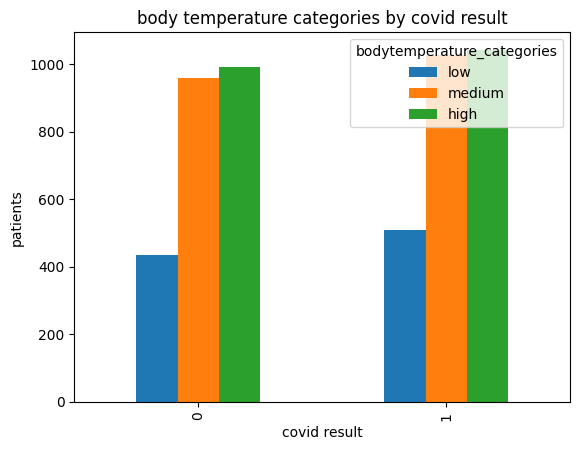

In [658]:
table.plot(kind='bar')
plt.title("body temperature categories by covid result")
plt.xlabel("covid result")
plt.ylabel("patients")
plt.show()

In [659]:
print(df.groupby('comorbidity')['covid_result'].value_counts())

comorbidity         covid_result
Asthma              1                252
                    0                230
Diabetes            1                510
                    0                491
Heart Disease       0                397
                    1                395
no chronic disease  1               1443
                    0               1282
Name: count, dtype: int64


In [660]:
print(df.groupby('oxygen_level')['covid_result'].value_counts())

oxygen_level  covid_result
85            1               222
              0               104
86            1               247
              0               100
87            1               245
              0               100
88            1               225
              0               102
89            1               255
              0                92
90            1               240
              0                97
91            1               252
              0                94
92            0               206
              1               109
93            0               234
              1               119
94            0               223
              1                98
95            0               212
              1               120
96            0               218
              1               123
97            0               213
              1               101
98            0               217
              1               122
99            0      

# Statistical Analysis & Hypothesis Testing 

### Here i am choosing chi-square test which is used to find the relationship between two categorical variables

### Null Hypothesis: Taking null hypothesis as there is no relationship between gender and fever variables
### Alternative Hypothesis: Taking alternative hypothesis as there is a relationship between gender and fever variables

### Contingency Table

In [661]:
contingency_table = pd.crosstab(df["gender"],df["fever"])
print("contingency_table:-\n", contingency_table)

contingency_table:-
 fever      0     1
gender            
Female  1096  1418
Male    1067  1419


### Visualization for contingency table

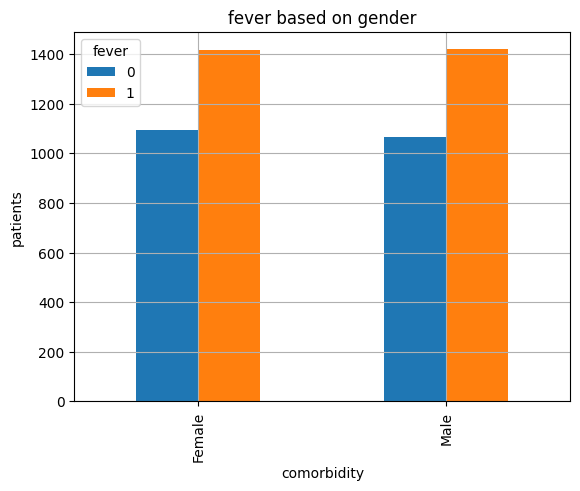

In [662]:
import matplotlib.pyplot as plt
contingency_table.plot(kind='bar')

plt.title("fever based on gender")
plt.xlabel("comorbidity")
plt.ylabel("patients")

plt.grid()
plt.show()

### Observed Values

In [663]:
observed_values = contingency_table.values
print("observed_values:-\n", observed_values)

observed_values:-
 [[1096 1418]
 [1067 1419]]


### Expected Values

In [664]:
import scipy.stats
b = scipy.stats.chi2_contingency(contingency_table)
expected_values = b[3]
print("expected_values:-\n", expected_values)

expected_values:-
 [[1087.5564 1426.4436]
 [1075.4436 1410.5564]]


### Degree of Freedom

In [665]:
no_of_rows=len(contingency_table.iloc[0:4,0])
no_of_columns=len(contingency_table.iloc[0,0:2])
degree_of_freedom =(no_of_rows-1)*(no_of_columns-1)
print("Degree of Freedom:-",degree_of_freedom)

Degree of Freedom:- 1


### Significance Level 5%

In [666]:
alpha = 0.05

### chi-square statistic - χ2

In [667]:
from scipy.stats import chi2
chi_square=sum([(o-e)**2./e for o,e in zip(observed_values,expected_values)])
chi_square_statistic=chi_square[0]+chi_square[1]
print("chi-square statistic:-",chi_square_statistic)

chi-square statistic:- 0.23237160760678172


### critical_value

In [668]:
critical_value=chi2.ppf(q=1-alpha,df=degree_of_freedom)
print('critical_value:',critical_value)

critical_value: 3.841458820694124


### p-value

In [669]:
p_value=1-chi2.cdf(x=chi_square_statistic,df=degree_of_freedom)
print('p-value:',p_value)

p-value: 0.6297708659579764


In [670]:
print('Significance level: ',alpha)
print('Degree of Freedom: ',degree_of_freedom)
print('chi-square statistic:',chi_square_statistic)
print('critical_value:',critical_value)
print('p-value:',p_value)


Significance level:  0.05
Degree of Freedom:  1
chi-square statistic: 0.23237160760678172
critical_value: 3.841458820694124
p-value: 0.6297708659579764


### compare chi_square_statistic with critical_value and p-value which is the probability of getting chi-square>0.09 (chi_square_statistic)

In [671]:
if chi_square_statistic>=critical_value:
    print("Reject H0,There is a relationship between 2 categorical variables")
else:
    print("fail to reject H0,There is no relationship between 2 categorical variables")
    
if p_value<=alpha:
    print("Reject H0,There is a relationship between 2 categorical variables")
else:
    print("fail to reject H0,There is no relationship between 2 categorical variables")

fail to reject H0,There is no relationship between 2 categorical variables
fail to reject H0,There is no relationship between 2 categorical variables


### Here i am trying to find relationship between covid_result and gender variables

### Null Hypothesis: Taking null hypothesis as there is no relationship between covid_result and fever variables
### Alternative Hypothesis: Taking alternative hypothesis as there is a relationship between covid_result and fever variables

In [672]:
contingency_table = pd.crosstab(df["covid_result"],df["fever"])
print("contingency_table:-\n", contingency_table)

contingency_table:-
 fever            0     1
covid_result            
0             1444   956
1              719  1881


In [673]:
observed_values = contingency_table.values
print("observed_values:-\n", observed_values)

observed_values:-
 [[1444  956]
 [ 719 1881]]


In [674]:
import scipy.stats
b = scipy.stats.chi2_contingency(contingency_table)
expected_values = b[3]
print("expected_values:-\n", expected_values)

expected_values:-
 [[1038.24 1361.76]
 [1124.76 1475.24]]


In [675]:
no_of_rows=len(contingency_table.iloc[0:2,0])
no_of_columns=len(contingency_table.iloc[0,0:2])
degree_of_freedom =(no_of_rows-1)*(no_of_columns-1)
print("Degree of Freedom:-",degree_of_freedom)

Degree of Freedom:- 1


In [676]:
alpha = 0.05

In [677]:
from scipy.stats import chi2
chi_square=sum([(o-e)**2./e for o,e in zip(observed_values,expected_values)])
chi_square_statistic=chi_square[0]+chi_square[1]
print("chi-square statistic:-",chi_square_statistic)

chi-square statistic:- 537.4623315768583


In [678]:
critical_value=chi2.ppf(q=1-alpha,df=degree_of_freedom)
print('critical_value:',critical_value)

critical_value: 3.841458820694124


In [679]:
p_value=1-chi2.cdf(x=chi_square_statistic,df=degree_of_freedom)
print('p-value:',p_value)

p-value: 0.0


In [680]:
print('Significance level: ',alpha)
print('Degree of Freedom: ',degree_of_freedom)
print('chi-square statistic:',chi_square_statistic)
print('critical_value:',critical_value)
print('p-value:',p_value)


Significance level:  0.05
Degree of Freedom:  1
chi-square statistic: 537.4623315768583
critical_value: 3.841458820694124
p-value: 0.0


In [681]:
if chi_square_statistic>=critical_value:
    print("Reject H0,There is a relationship between 2 categorical variables")
else:
    print("fail to reject H0,There is no relationship between 2 categorical variables")
    
if p_value<=alpha:
    print("Reject H0,There is a relationship between 2 categorical variables")
else:
    print("fail to reject H0,There is no relationship between 2 categorical variables")

Reject H0,There is a relationship between 2 categorical variables
Reject H0,There is a relationship between 2 categorical variables


# Statistical Analysis: Independent Two-Sample t-Test

### Null Hypothesis: Taking null hypothesis as there is no relationship between body_temperature and oxygen_level variables
### Alternative Hypothesis: Taking alternative hypothesis as there is a relationship between body_temperature and oxygen_level variables

In [682]:
import pandas as pd
from scipy.stats import ttest_ind

# Create groups using median (balanced split)
threshold = df['body_temperature'].median()

df['temp_group'] = df['body_temperature'].apply(
    lambda x: 'High' if x >= threshold else 'Normal'
)

# Extract oxygen levels
group1 = df[df['temp_group'] == 'High']['oxygen_level'].dropna()
group2 = df[df['temp_group'] == 'Normal']['oxygen_level'].dropna()

# Perform t-test
t_stat, p_value = ttest_ind(group1, group2)

print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value<=alpha:
    print("Reject H0,There is a relationship between 2 variables")
else:
    print("fail to reject H0,There is no relationship between 2 variables")

t-statistic: -0.04199209853598735
p-value: 0.9665066743639347
fail to reject H0,There is no relationship between 2 variables


In [683]:
table = pd.crosstab(df['temp_group'], df['oxygen_level'])
print(table)

oxygen_level   85   86   87   88   89   90   91   92   93   94   95   96   97  \
temp_group                                                                      
High          181  179  171  153  202  164  183  162  166  170  188  180  163   
Normal        145  168  174  174  145  173  163  153  187  151  144  161  151   

oxygen_level   98   99  
temp_group              
High          174  157  
Normal        165  153  


# Data Modeling

In this section, we build machine learning models to predict COVID-19 diagnosis.

We use patient age, symptom, clinical features:

- age
- fever
- dry_cough
- sore_throat
- fatigue
- headache
- shortness_of_breath
- loss_of_smell
- loss_of_taste
- chest_pain
- oxygen_level
- body_temperature

Two models are used:

1. Logistic Regression (baseline model)  
2. Random Forest (advanced model)

The target variable is:

- covid_result

In [684]:
import pandas as pd
import numpy as np


df = pd.read_csv("data/covid19_patient_symptoms_diagnosis.csv")

df_cleaned = df.copy()

# fill missing values in comorbidity
df_cleaned["comorbidity"] = df_cleaned["comorbidity"].fillna("None")

# symptom columns
symptoms = [
    "fever", "dry_cough", "sore_throat", "fatigue", "headache",
    "shortness_of_breath", "loss_of_smell", "loss_of_taste", "chest_pain"
]


In [685]:
print(df_cleaned.head())

   patient_id  age  gender  fever  dry_cough  sore_throat  fatigue  headache  \
0           1   52    Male      1          0            1        1         0   
1           2   15    Male      0          0            0        1         1   
2           3   72    Male      1          0            1        0         0   
3           4   61  Female      0          0            1        1         1   
4           5   21  Female      1          1            0        0         0   

   shortness_of_breath  loss_of_smell  loss_of_taste  oxygen_level  \
0                    0              0              0            98   
1                    0              0              0            85   
2                    1              0              1            99   
3                    0              1              1            86   
4                    1              0              1            90   

   body_temperature comorbidity  travel_history  contact_with_patient  \
0              37.1    Di

In [686]:
# select features and target

features = ["age","oxygen_level","body_temperature","fever","dry_cough","sore_throat","fatigue","headache","shortness_of_breath","loss_of_smell","loss_of_taste","chest_pain"]

X = df_cleaned[features]
y = df_cleaned["covid_result"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (5000, 12)
Target shape: (5000,)


In [687]:
from sklearn.model_selection import train_test_split

# split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 12)
Testing data: (1000, 12)


## Baseline Model: Logistic Regression

In [688]:
from sklearn.linear_model import LogisticRegression

# create and train logistic regression model
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

# make predictions
y_pred_log = log_model.predict(X_test)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [689]:
from sklearn.metrics import accuracy_score

# calculate accuracy
accuracy_log = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", round(accuracy_log, 3))

Logistic Regression Accuracy: 0.818


## Advanced Model: Random Forest

In [690]:
from sklearn.ensemble import RandomForestClassifier

# create and train random forest model
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

# make predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [691]:
# calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(accuracy_rf, 3))

Random Forest Accuracy: 0.861


# Model Comparison

Logistic Regression Accuracy: 0.818  
Random Forest Accuracy: 0.861  

Both models performed well in predicting COVID-19 diagnosis.

Random Forest achieved higher accuracy than Logistic Regression, so it was the better-performing model on this dataset.

This suggests that patient symptoms, oxygen level, body temperature, and age are useful predictors of COVID-19 diagnosis.

In [692]:
from sklearn.metrics import confusion_matrix

# confusion matrix for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix (Random Forest):")
print(cm)

Confusion Matrix (Random Forest):
[[457  48]
 [ 91 404]]


## Confusion Matrix Interpretation

The confusion matrix shows that the Random Forest model correctly classified most patients, with relatively few incorrect predictions.

This supports the higher accuracy achieved by the Random Forest model.

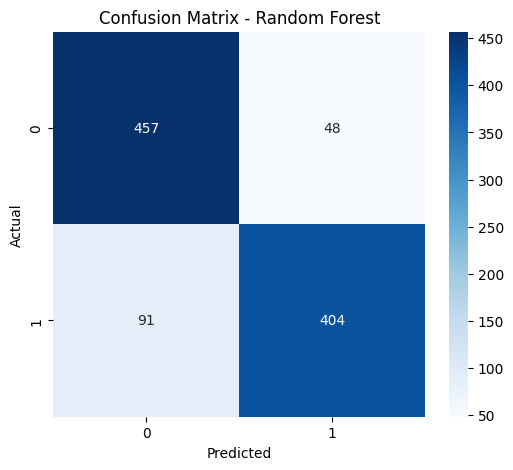

In [693]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()